# Preprocessing Pipeline

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt 
import cv2
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

RAW_ROOT  = Path('../dataset/raw')
PROC_ROOT = Path('../dataset/processed')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_TRAIN_IMG = RAW_ROOT / 'train' / 'images'
RAW_TRAIN_MSK = RAW_ROOT / 'train' / 'masks'
RAW_TEST_IMG  = RAW_ROOT / 'test'  / 'images'
RAW_TEST_MSK  = RAW_ROOT / 'test'  / 'masks'

IMAGE_SIZE  = 224
VAL_FRAC    = 0.15
CLAHE_CLIP  = 2.0
CLAHE_GRID  = (8, 8)
MASK_THRESH = 127

print('Path check ')
for d in [RAW_TRAIN_IMG, RAW_TRAIN_MSK, RAW_TEST_IMG, RAW_TEST_MSK]:
    status = 'Present' if d.exists() else ' MISSING'
    print(f'  {status}  {d}')

Path check 
  Present  ../dataset/raw/train/images
  Present  ../dataset/raw/train/masks
  Present  ../dataset/raw/test/images
  Present  ../dataset/raw/test/masks


## Split Information

In [2]:
def list_pairs(img_dir: Path, msk_dir: Path) -> list:
    imgs = sorted(img_dir.glob('*.jpg'))
    msks = sorted(msk_dir.glob('*.png'))
    assert len(imgs) == len(msks), (f'Count mismatch: {len(imgs)} images vs {len(msks)} masks in {img_dir}')
    for i, m in zip(imgs, msks):
        assert i.stem == m.stem, f'Stem mismatch: {i.stem} vs {m.stem}'
    return list(zip(imgs, msks))

all_train_pairs = list_pairs(RAW_TRAIN_IMG, RAW_TRAIN_MSK)
test_pairs = list_pairs(RAW_TEST_IMG,  RAW_TEST_MSK)
train_pairs, val_pairs = train_test_split(all_train_pairs, test_size=VAL_FRAC, random_state=SEED)

print('Split sizes :')
print(f'  Train : {len(train_pairs)}')
print(f'  Val   : {len(val_pairs)}')
print(f'  Test  : {len(test_pairs)}')
print(f'  Total : {len(train_pairs) + len(val_pairs) + len(test_pairs)}')
print(f'\nSample train pair : {train_pairs[0][0].name}')
print(f'Sample val pair   : {val_pairs[0][0].name}')
print(f'Sample test pair  : {test_pairs[0][0].name}')

Split sizes :
  Train : 3343
  Val   : 590
  Test  : 860
  Total : 4793

Sample train pair : brisc2025_train_04856_pi_sa_t1.jpg
Sample val pair   : brisc2025_train_04992_pi_sa_t1.jpg
Sample test pair  : brisc2025_test_00001_gl_ax_t1.jpg


In [3]:
for split in ['train', 'val', 'test']:
    for sub in ['images', 'masks']:
        (PROC_ROOT / split / sub).mkdir(parents=True, exist_ok=True)

print('Output directory structure:')
for split in ['train', 'val', 'test']:
    for sub in ['images', 'masks']:
        print(f'{PROC_ROOT / split / sub}')

Output directory structure:
../dataset/processed/train/images
../dataset/processed/train/masks
../dataset/processed/val/images
../dataset/processed/val/masks
../dataset/processed/test/images
../dataset/processed/test/masks


## Processing functions

In [4]:
def load_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert('L'), dtype=np.float32)

def load_mask(path: Path) -> np.ndarray:
    m = np.array(Image.open(path).convert('L'), dtype=np.float32)
    return (m > MASK_THRESH).astype(np.uint8)

def apply_clahe(img: np.ndarray) -> np.ndarray:
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    return clahe.apply(img_u8).astype(np.float32)

def zscore_normalise(img: np.ndarray) -> np.ndarray:
    brain = img[img > 0]
    if len(brain) == 0:
        return img
    mean, std = brain.mean(), brain.std()
    if std < 1e-8:
        return img - mean
    return (img - mean) / std

def resize_image(img: np.ndarray, size: int = IMAGE_SIZE) -> np.ndarray:
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)

def resize_mask(msk: np.ndarray, size: int = IMAGE_SIZE) -> np.ndarray:
    return cv2.resize(msk.astype(np.float32), (size, size), interpolation=cv2.INTER_NEAREST).astype(np.uint8)

def process_pair(img_path: Path, msk_path: Path):
    img = load_image(img_path)
    msk = load_mask(msk_path)
    img = apply_clahe(img)
    img = zscore_normalise(img)
    img = resize_image(img)
    msk = resize_mask(msk)
    return img, msk

## Visualization

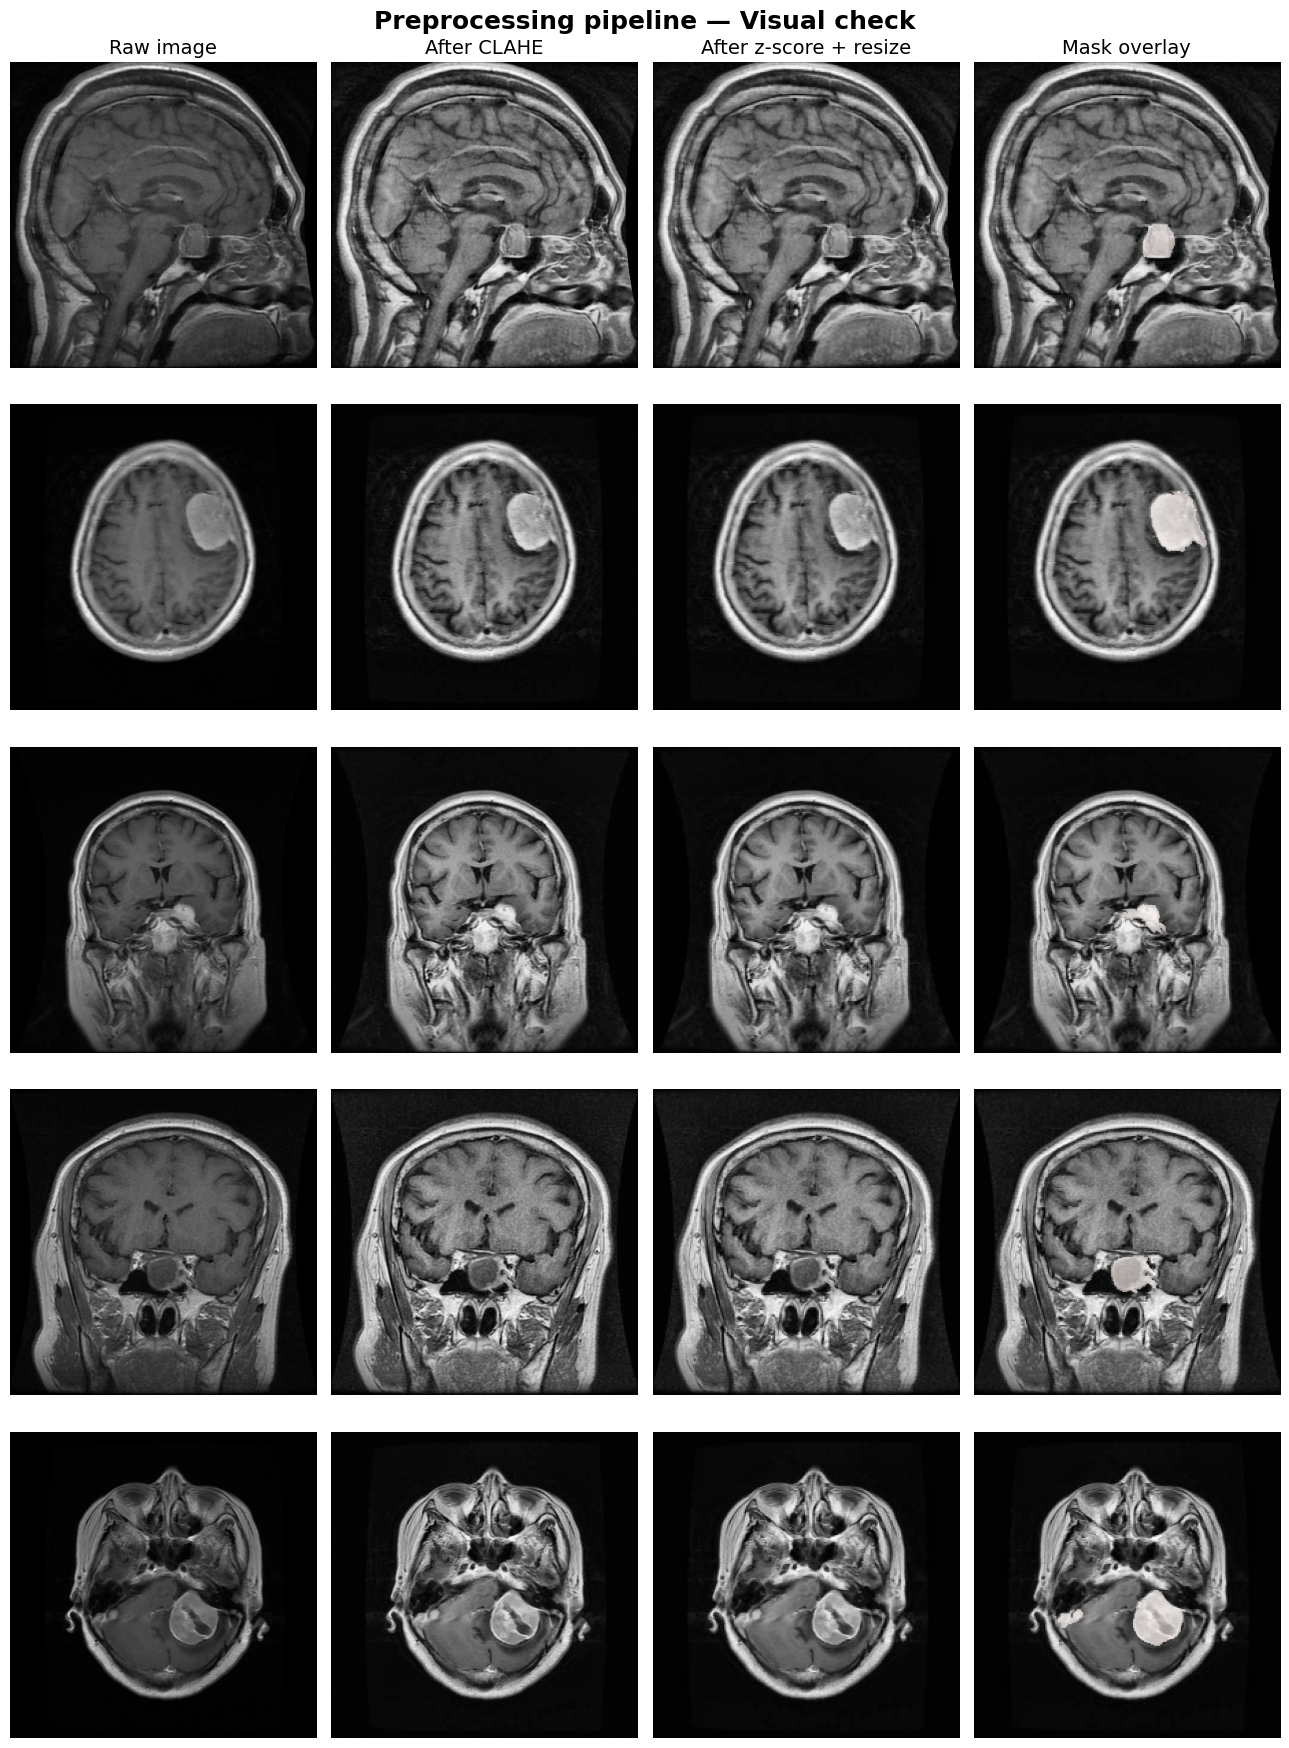

In [ ]:
check_pairs = []
for img_f, msk_f in train_pairs:
    raw_msk = np.array(Image.open(msk_f).convert('L'))
    if (raw_msk > MASK_THRESH).sum() > 0:
        check_pairs.append((img_f, msk_f))
    if len(check_pairs) == 5:
        break

fig, axes = plt.subplots(5, 4, figsize=(13,18)) 
col_titles = ['Raw image', 'After CLAHE', 'After z-score + resize', 'Mask overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14)

for row, (img_f, msk_f) in enumerate(check_pairs):
    raw_img = load_image(img_f)
    raw_msk = load_mask(msk_f)
    
    clahe_img = apply_clahe(raw_img)
    norm_img = zscore_normalise(clahe_img)
    final_img = resize_image(norm_img)
    final_msk = resize_mask(raw_msk)

    axes[row,0].imshow(raw_img,cmap='gray')
    axes[row,0].set_ylabel(img_f.name[:22], fontsize=7)
    
    axes[row,1].imshow(clahe_img,cmap='gray')
    axes[row,2].imshow(final_img,cmap='gray')
    axes[row,3].imshow(final_img,cmap='gray')
    axes[row,3].imshow(np.ma.masked_where(final_msk == 0,final_msk),cmap='Reds',alpha=0.55)
    for col in range(4):
        axes[row, col].axis('off')

plt.suptitle('Preprocessing pipeline — Visual check', fontweight='bold',fontsize = 18)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'preprocessing_visual_check.png', dpi=120, bbox_inches='tight')
plt.show()

### Main Preprocessing Loop 

In [6]:
def run_split(pairs: list, split_name: str):
    out_img_dir = PROC_ROOT / split_name / 'images'
    out_msk_dir = PROC_ROOT / split_name / 'masks'
    for img_f, msk_f in tqdm(pairs, desc=f'{split_name:5}', unit='img'):
        img, msk = process_pair(img_f, msk_f)
        stem = img_f.stem
        np.save(str(out_img_dir / f'{stem}.npy'), img)
        np.save(str(out_msk_dir / f'{stem}.npy'), msk)


print('Starting preprocessing\n')
run_split(train_pairs, 'train')
run_split(val_pairs,   'val')
run_split(test_pairs,  'test')
print('\nAll splits done')

Starting preprocessing



train:   0%|          | 0/3343 [00:00<?, ?img/s]

val  :   0%|          | 0/590 [00:00<?, ?img/s]

test :   0%|          | 0/860 [00:00<?, ?img/s]


All splits done


In [7]:
print('Output file Count Verification\n')
expected = {'train': len(train_pairs), 'val': len(val_pairs), 'test': len(test_pairs)}
all_ok = True

for split in ['train', 'val', 'test']:
    saved_imgs = list((PROC_ROOT / split / 'images').glob('*.npy'))
    saved_msks = list((PROC_ROOT / split / 'masks').glob('*.npy'))
    match = len(saved_imgs) == expected[split] and len(saved_imgs) == len(saved_msks)
    status = '' if match else 'MISMATCH'
    if not match:
        all_ok = False
    print(f'  {status}  {split:5} — images: {len(saved_imgs)}  '
          f'masks: {len(saved_msks)}  (expected {expected[split]})')

print()
print('All counts match ' if all_ok else 'WARNING: count mismatch — recheck!')

Output file Count Verification

    train — images: 3343  masks: 3343  (expected 3343)
    val   — images: 590  masks: 590  (expected 590)
    test  — images: 860  masks: 860  (expected 860)

All counts match 


In [8]:
print('Array property checks\n')

for split in ['train', 'val', 'test']:
    img_files = sorted((PROC_ROOT / split / 'images').glob('*.npy'))
    msk_files = sorted((PROC_ROOT / split / 'masks').glob('*.npy'))

    img = np.load(str(img_files[0]))
    msk = np.load(str(msk_files[0]))

    print(f'  [{split}]  {img_files[0].name}')
    print(f'    image — shape: {img.shape}  dtype: {img.dtype}  '
          f'min: {img.min():.3f}  max: {img.max():.3f}')
    print(f'    mask  — shape: {msk.shape}  dtype: {msk.dtype}  '
          f'  unique values: {np.unique(msk).tolist()}')
    print()

assert img.shape == (IMAGE_SIZE, IMAGE_SIZE), f'Expected ({IMAGE_SIZE},{IMAGE_SIZE}), got {img.shape}'
assert img.dtype == np.float32,f'Expected float32, got {img.dtype}'
assert msk.shape == (IMAGE_SIZE, IMAGE_SIZE), f'Expected ({IMAGE_SIZE},{IMAGE_SIZE}), got {msk.shape}'
assert msk.dtype == np.uint8,f'Expected uint8, got {msk.dtype}'
assert set(np.unique(msk)).issubset({0, 1}),  f'Mask not binary: {np.unique(msk)}'
print('All assertions passed')

Array property checks

  [train]  brisc2025_train_00001_gl_ax_t1.npy
    image — shape: (224, 224)  dtype: float32  min: -0.897  max: 3.270
    mask  — shape: (224, 224)  dtype: uint8    unique values: [0, 1]

  [val]  brisc2025_train_00004_gl_ax_t1.npy
    image — shape: (224, 224)  dtype: float32  min: -0.758  max: 5.183
    mask  — shape: (224, 224)  dtype: uint8    unique values: [0, 1]

  [test]  brisc2025_test_00001_gl_ax_t1.npy
    image — shape: (224, 224)  dtype: float32  min: -0.812  max: 3.429
    mask  — shape: (224, 224)  dtype: uint8    unique values: [0, 1]

All assertions passed


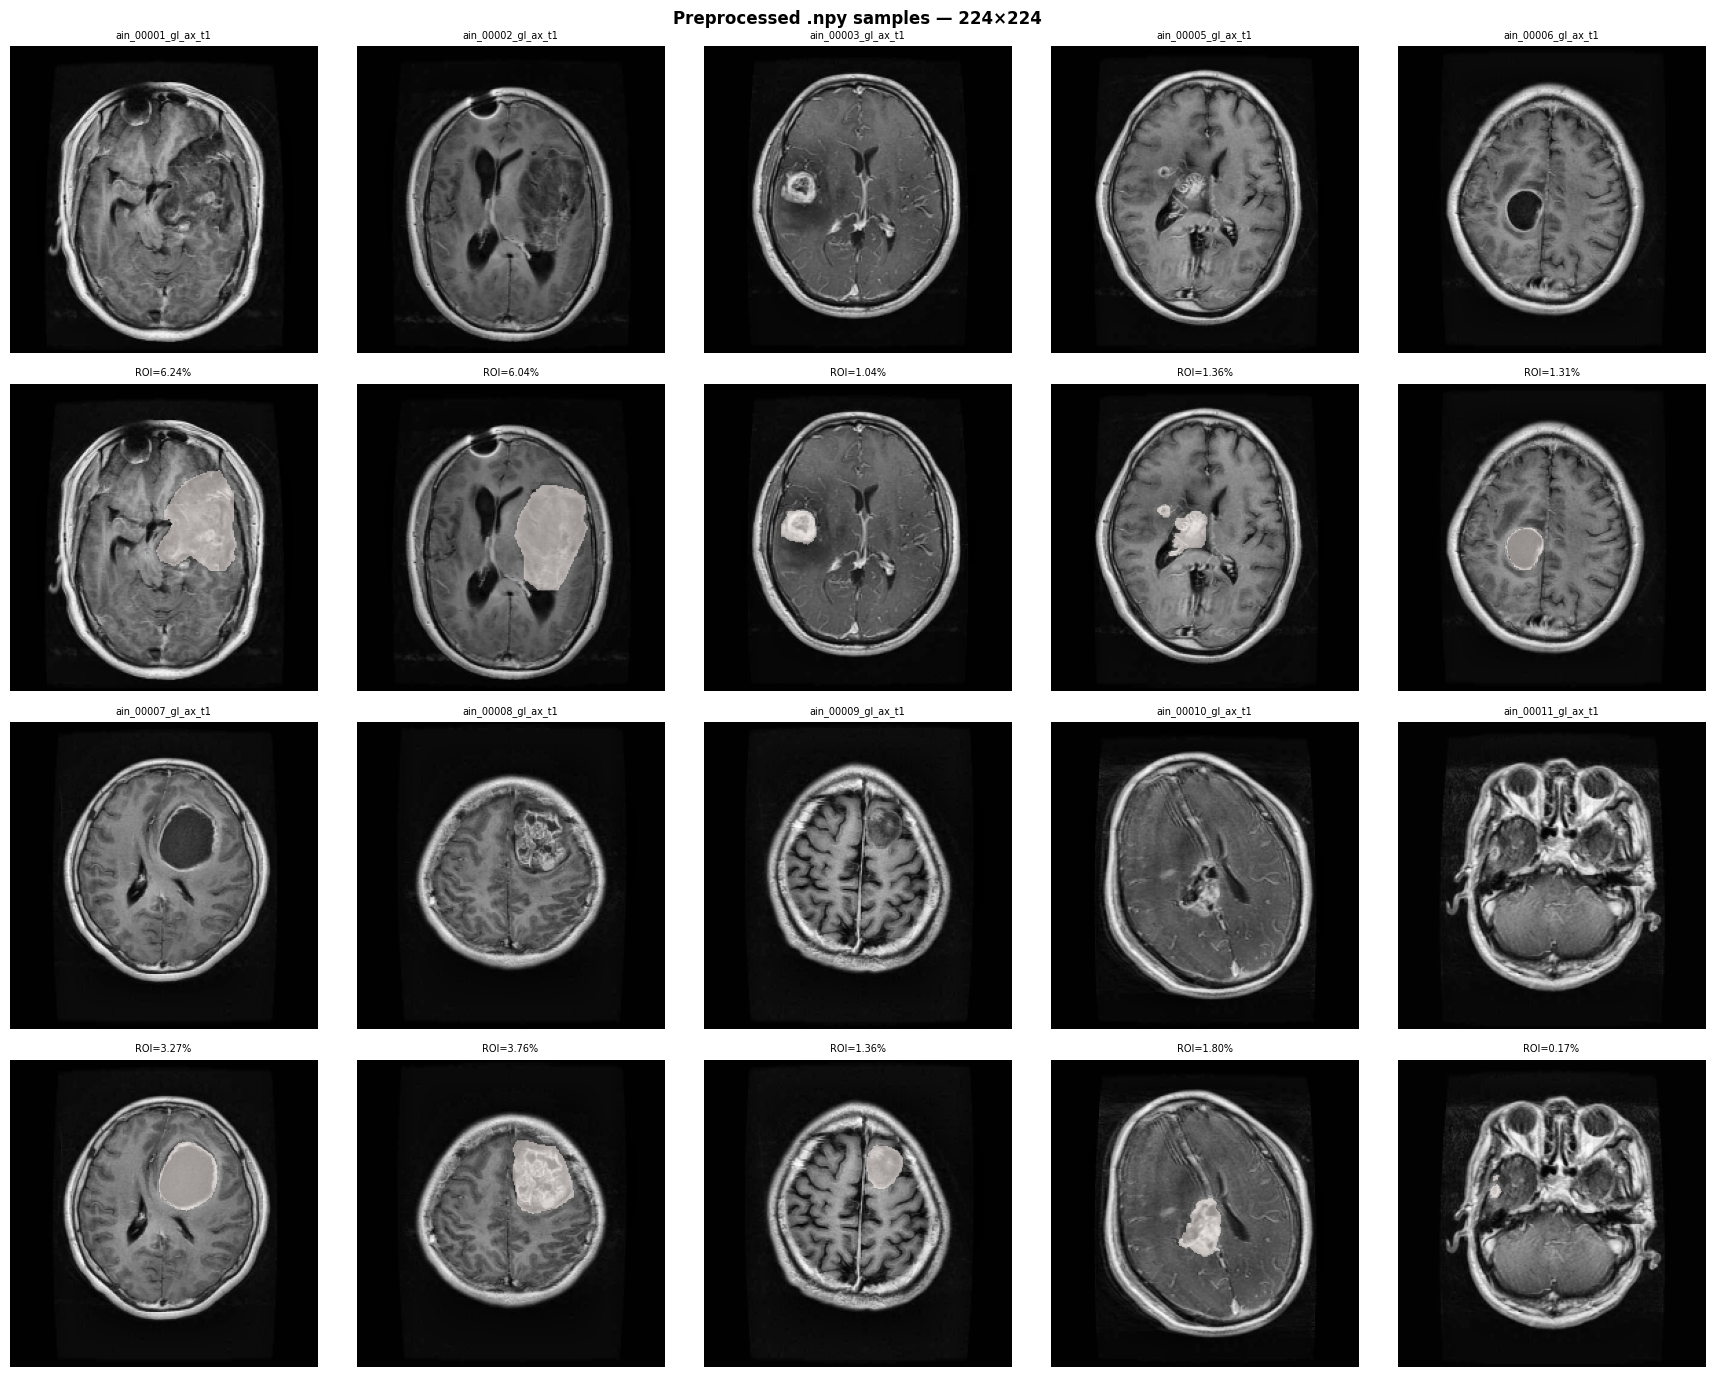

Overlay grid saved.


In [9]:
N_SHOW = 10
N_COLS = 5
N_ROWS = (N_SHOW + N_COLS - 1) // N_COLS

saved_imgs = sorted((PROC_ROOT / 'train' / 'images').glob('*.npy'))[:N_SHOW]
saved_msks = sorted((PROC_ROOT / 'train' / 'masks').glob('*.npy'))[:N_SHOW]

fig, axes = plt.subplots(N_ROWS * 2, N_COLS, figsize=(N_COLS * 3.5, N_ROWS * 7))

for idx, (img_f, msk_f) in enumerate(zip(saved_imgs, saved_msks)):
    row = (idx // N_COLS) * 2
    col = idx % N_COLS
    img = np.load(str(img_f))
    msk = np.load(str(msk_f))
    roi = msk.mean() * 100

    axes[row,col].imshow(img, cmap='gray')
    axes[row,col].set_title(img_f.stem[-18:], fontsize=7)
    axes[row,col].axis('off')

    axes[row + 1, col].imshow(img, cmap='gray')
    axes[row + 1, col].imshow(np.ma.masked_where(msk == 0, msk), cmap='Reds', alpha=0.55)
    axes[row + 1, col].set_title(f'ROI={roi:.2f}%', fontsize=7)
    axes[row + 1, col].axis('off')

plt.suptitle(f'Preprocessed .npy samples — {IMAGE_SIZE}×{IMAGE_SIZE}', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'preprocessing_output_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Overlay grid saved.')

### Class imbalance

In [11]:
print(' Foreground Pixel per split\n')

for split in ['train', 'val', 'test']:
    msk_files = sorted((PROC_ROOT / split / 'masks').glob('*.npy'))
    ratios = []
    empty  = 0
    for msk_f in tqdm(msk_files, desc=split, leave=False):
        r = np.load(str(msk_f)).mean() * 100
        ratios.append(r)
        if r == 0:
            empty += 1

    ratios = np.array(ratios)
    extreme = (ratios < 2).sum()

    print(f'  [{split}]')
    print(f'    mean={ratios.mean():.3f}%  median={np.median(ratios):.3f}%  '
          f'min={ratios.min():.3f}%  max={ratios.max():.3f}%')
    print(f'    empty masks : {empty} / {len(ratios)}')
    print(f'    masks < 2%  : {extreme} ({extreme/len(ratios)*100:.1f}%)')
    print()

 Foreground Pixel per split



train:   0%|          | 0/3343 [00:00<?, ?it/s]

  [train]
    mean=1.652%  median=1.264%  min=0.008%  max=17.407%
    empty masks : 0 / 3343
    masks < 2%  : 2443 (73.1%)



val:   0%|          | 0/590 [00:00<?, ?it/s]

  [val]
    mean=1.624%  median=1.250%  min=0.096%  max=8.438%
    empty masks : 0 / 590
    masks < 2%  : 430 (72.9%)



test:   0%|          | 0/860 [00:00<?, ?it/s]

  [test]
    mean=1.906%  median=1.241%  min=0.082%  max=15.464%
    empty masks : 0 / 860
    masks < 2%  : 598 (69.5%)

